In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10
class0_color = "#4C78A8"
class1_color = "#F58518"
test_edge_color = "black"
misclassified_color = "red"
boundary_color = "#5B006E"

In [6]:
X , y = make_moons(n_samples = 300 , noise = 0.22 , random_state = 42)
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.25 , stratify = y , random_state = 42
)
model = LogisticRegression()
model.fit(X_train , y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_acc = accuracy_score(y_train , y_train_pred)
test_acc = accuracy_score(y_test , y_test_pred)
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

LogisticRegression()

Training accuracy: 0.871
Test accuracy: 0.827


<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Toy Dataset for Week 7')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

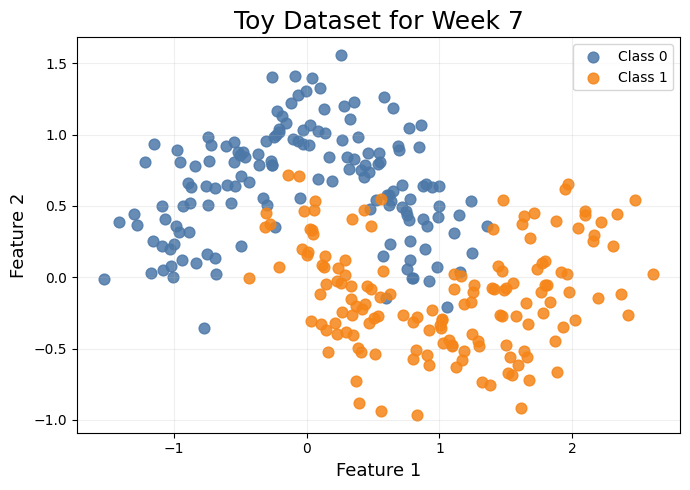

In [7]:
plt.figure()
plt.scatter(X[y == 0 , 0] , X[y == 0 , 1] , s = 60 , alpha = 0.85 ,
            color = class0_color , label = "Class 0")
plt.scatter(X[y == 1 , 0] , X[y == 1 , 1] , s = 60 , alpha = 0.85 ,
            color = class1_color , label = "Class 1")
plt.title("Toy Dataset for Week 7")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Same Dataset, Different Roles: Train vs Test')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

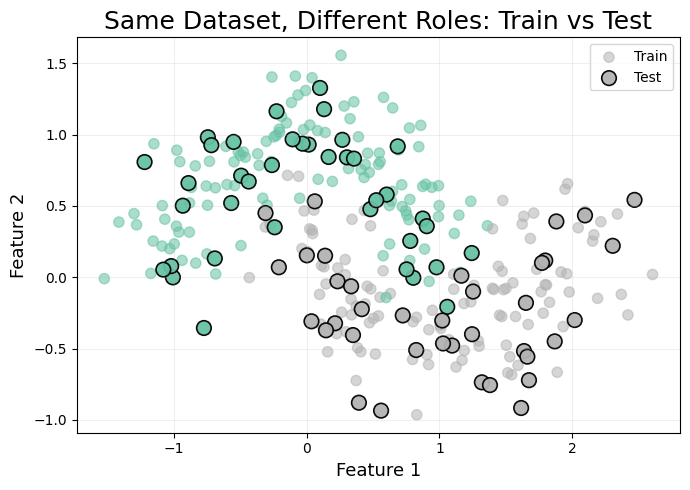

In [8]:
plt.figure()
plt.scatter(X_train[ : , 0] , X_train[ : , 1] , c = y_train , cmap = plt.cm.Set2 ,
            s = 55 , alpha = 0.55 , label = "Train")
plt.scatter(X_test[ : , 0] , X_test[ : , 1] , c = y_test , cmap = plt.cm.Set2 ,
            s = 110 , alpha = 0.95 , edgecolor = test_edge_color ,
            linewidth = 1.2 , label = "Test")
plt.title("Same Dataset, Different Roles: Train vs Test")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
x_min , x_max = X[ : , 0].min() - 0.8 , X[ : , 0].max() + 0.8
y_min , y_max = X[ : , 1].min() - 0.8 , X[ : , 1].max() + 0.8
xx , yy = np.meshgrid(
    np.linspace(x_min , x_max , 400) , np.linspace(y_min , y_max , 400)
)
grid = np.c_[xx.ravel() , yy.ravel()]
Z_class = model.predict(grid).reshape(xx.shape)
Z_prob = model.predict_proba(grid)[ : , 1].reshape(xx.shape)

<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Baseline Logistic Regression Decision Boundary')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

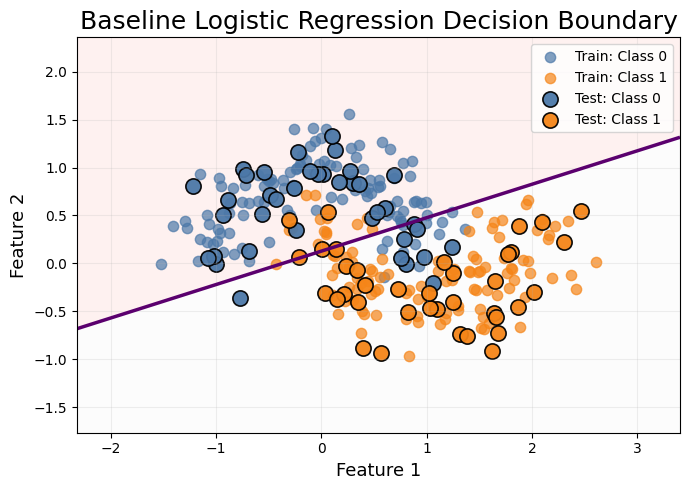

In [10]:
plt.figure()
plt.contourf(xx , yy , Z_class , alpha = 0.18 , cmap = plt.cm.Pastel1)
plt.contour(xx , yy , Z_prob , levels = [0.5] , colors = boundary_color ,
            linewidths = 2.5)
plt.scatter(X_train[y_train == 0 , 0] , X_train[y_train == 0 , 1] , s = 55 ,
            alpha = 0.70 , color = class0_color , label = "Train: Class 0")
plt.scatter(X_train[y_train == 1 , 0] , X_train[y_train == 1 , 1] , s = 55 ,
            alpha = 0.70 , color = class1_color , label = "Train: Class 1")
plt.scatter(X_test[y_test == 0 , 0] , X_test[y_test == 0 , 1] , s = 120 ,
            alpha = 0.95 , color = class0_color , edgecolor = test_edge_color ,
            linewidth = 1.2 , label = "Test: Class 0")
plt.scatter(X_test[y_test == 1 , 0] , X_test[y_test == 1 , 1] , s = 120 ,
            alpha = 0.95 , color = class1_color , edgecolor = test_edge_color ,
            linewidth = 1.2 , label = "Test: Class 1")
plt.title("Baseline Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc = "upper right")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Where the Baseline Gets It Wrong')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

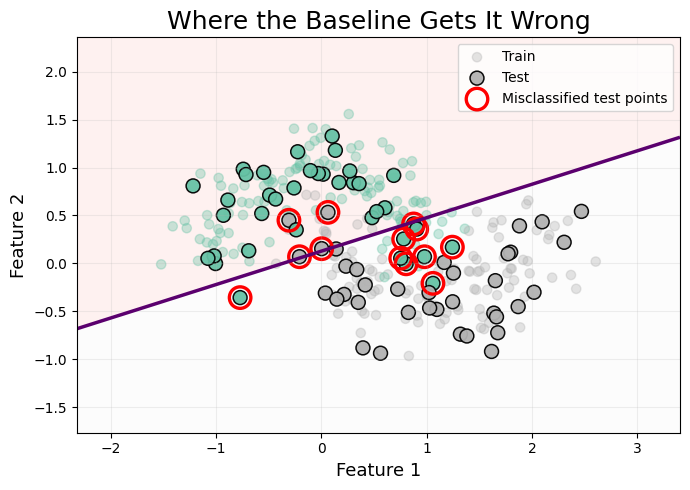

In [11]:
misclassified = (y_test != y_test_pred)

plt.figure()
plt.contourf(xx , yy , Z_class , alpha = 0.18 , cmap = plt.cm.Pastel1)
plt.contour(xx , yy , Z_prob , levels = [0.5] , colors = boundary_color , linewidths = 2.5)
plt.scatter(X_train[ : , 0] , X_train[ : , 1] , c = y_train , cmap = plt.cm.Set2 ,
            s = 45 , alpha = 0.35 , label = "Train")
plt.scatter(X_test[ : , 0] , X_test[ : , 1] , c = y_test , cmap = plt.cm.Set2 ,
            s = 100 , alpha = 0.95 , edgecolor = test_edge_color ,
            linewidth = 1.1 , label = "Test")
plt.scatter(X_test[misclassified , 0] , X_test[misclassified , 1] , s = 240 ,
            facecolors = "none" , edgecolors = misclassified_color ,
            linewidth = 2.4 , label = "Misclassified test points")
plt.title("Where the Baseline Gets It Wrong")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc = "upper right")
plt.tight_layout()
plt.show()

In [15]:
n_errors = misclassified.sum()
n_test = len(y_test)
print("=" * 40)
print("=============== Summary ================")
print("=" * 40)
print(f"Train accuracy : {train_acc:.3f}")
print(f"Test accuracy : {test_acc:.3f}")
print(f"Test errors : {n_errors} out of {n_test}")
print("\nInterpretation:")
print("Logistic regression is a strong baseline,")
print("but even a reasonable train/test score can hide mistakes near complex boundaries.")
print("That is exactly why model selection and cross-validation matter.")

=============== Summary ================
Train accuracy : 0.871
Test accuracy : 0.827
Test errors : 13 out of 75

Interpretation:
Logistic regression is a strong baseline,
but even a reasonable train/test score can hide mistakes near complex boundaries.
That is exactly why model selection and cross-validation matter.
